# Contextualização do Problema

## Definição do Problema

Este trabalho tem como objetivo identificar a presença de **câncer** em pacientes utilizando técnicas de *machine learning supervisionado*.

Os principais pontos abordados são:

- Análise exploratória dos dados
- Pré-processamento e limpeza
- Treinamento de múltiplos modelos
- Avaliação de desempenho

## Definição do Problema

Texto a ser incluído
## Descrição do Dataset

Link: https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors

Quantidade de Registros: 858

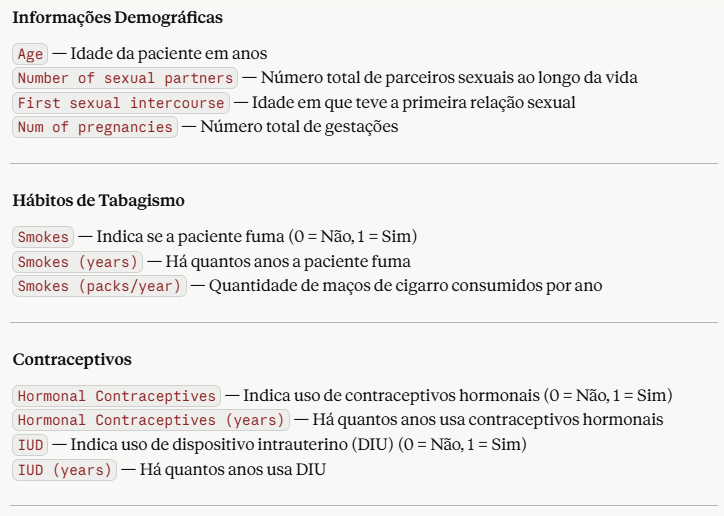

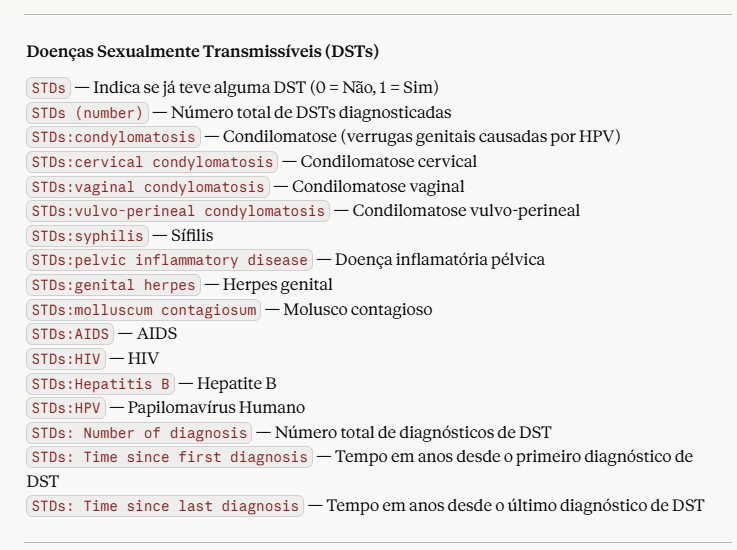



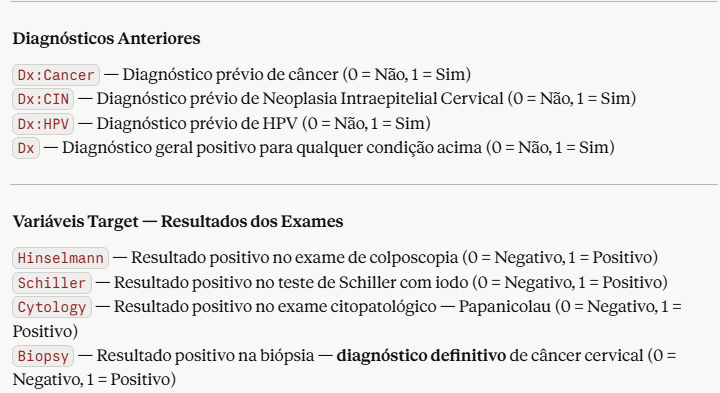


#Configuração do Ambiente e Importação de Bibliotecas

In [234]:
# ====================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ====================================================

# --- Manipulação de dados ---
import pandas as pd
import numpy as np
from scipy import stats

# --- Integração externa ---
from google.colab import drive

# --- Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Pré-processamento ---
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# --- Divisão e validação ---
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
    StratifiedKFold
)

# --- Modelos ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# --- Métricas de avaliação ---
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
    RocCurveDisplay
)

In [235]:
# ====================================================
# CARREGAMENTO DO DATASET
# ====================================================

# --- Montagem do arquivo a partir do Git Hub ---
url = "https://raw.githubusercontent.com/gilbertoag2007/fiap-tech-challenge-fase1/main/kag_risk_factors_cervical_cancer.csv"
df_original = pd.read_csv(url)

# --- Coluna Target ---
target = 'Biopsy'


# Pré-Processamento Inicial

In [236]:
# ====================================================
# VISUALIZAÇÃO INICIAL
# ====================================================

df_original.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [237]:
# ====================================================
# ANALISANDO OS TIPOS DE COLUNAS E EXEMPLO DE VALORES
# ====================================================

qtd_registros, qtd_colunas = df_original.shape
print(f"Registros: {qtd_registros} | Colunas: {qtd_colunas}")


resumo = pd.DataFrame({
    'Tipo': df_original.dtypes,
    'Valores Únicos': df_original.nunique(),
    'Qtd Null': df_original.isnull().sum(),
    'Exemplos': [
        sorted(df_original[col].dropna().unique())[:5]
        for col in df_original.columns
    ]
})

display(resumo)

# RELATÓRIO - A partir do resultado abaixo é possível identificar que alguns valores  "?" e precisam ser tratados

Registros: 858 | Colunas: 36


,Tipo,Valores Únicos,Qtd Null,Exemplos
Age,int64,44,0,"[13, 14, 15, 16, 17]"
Number of sexual partners,object,13,0,"[1.0, 10.0, 15.0, 2.0, 28.0]"
First sexual intercourse,object,22,0,"[10.0, 11.0, 12.0, 13.0, 14.0]"
Num of pregnancies,object,12,0,"[0.0, 1.0, 10.0, 11.0, 2.0]"
Smokes,object,3,0,"[0.0, 1.0, ?]"
Smokes (years),object,31,0,"[0.0, 0.16, 0.5, 1.0, 1.266972909]"
Smokes (packs/year),object,63,0,"[0.0, 0.001, 0.003, 0.025, 0.04]"
Hormonal Contraceptives,object,3,0,"[0.0, 1.0, ?]"
Hormonal Contraceptives (years),object,41,0,"[0.0, 0.08, 0.16, 0.17, 0.25]"
IUD,object,3,0,"[0.0, 1.0, ?]"


In [238]:
# ====================================================
# IDENTIFICANDO E TRATANDO REGISTROS DUPLICADOS
# ====================================================

# Conta duplicatas (exceto a primeira ocorrência)
qtd_duplicatas = df_original.duplicated().sum()

if qtd_duplicatas == 0:
    print("✅ Nenhum registro duplicado encontrado.")
else:
    print(f"⚠️ {qtd_duplicatas} registro(s) duplicado(s) encontrado(s).")

# Remove duplicatas e reset os indices do dataset
df_tratado = df_original.drop_duplicates().reset_index(drop=True)

if qtd_duplicatas > 0:
    print(f"✅ Duplicatas removidas. O dataset agora possui {len(df_tratado)} registros.")

# RELATÓRIO - Removendo registros duplicados do dataset e reset os indices dos registros após a remoção

⚠️ 23 registro(s) duplicado(s) encontrado(s).
✅ Duplicatas removidas. O dataset agora possui 835 registros.


In [239]:
# =============================================================
# CONVERTENDO DTYPE NÃO NUMERICOS PARA NUMERICOS
# =============================================================

# RELATÓRIO -
# 1 - Considerando que a dataset só possui features numéricas e binarias (0 e 1), a logica a seguir vai identificar os valores não
# numéricos em cada coluna e tentar converter os valores com ? por NaN que é que é reconhecido em colunas numéricas.

# 2 - O DType das colunas também serão convertidos de object para float64 ou int64.
# A conversão para Dtype numéricos é necessária para apresentação de bloxpot, histogramas e utilização de modelos como: Random Forest, Regressão Logística, XGBClassifier, KNM e SVM.

df_tratado = df_tratado.copy()

encontrou = False

df_tratado_antes = df_tratado.copy()


print('Remove espaços vazios e caracteres invisíveis por NaN')
for col in df_tratado.select_dtypes(include='object').columns:
    df_tratado.loc[:, col] = df_tratado[col].str.strip()
    df_tratado.loc[:, col] = df_tratado[col].str.replace('\xa0', '', regex=False)
    df_tratado.loc[:, col] = df_tratado[col].str.replace('\t',   '', regex=False)

print('Substitui valores não numéricos para NaN e converte coluna de object para float ou int')
for col in df_tratado.columns:
    mascara = pd.to_numeric(df_tratado[col], errors='coerce').isna() & df_tratado[col].notna()

    if mascara.sum() > 0:
        encontrou = True
        valores_antes = df_tratado_antes[col][mascara].unique()

        df_tratado[col] = pd.to_numeric(df_tratado[col], errors='coerce')

        print(f"Coluna             : {col} — Tipo Original: {df_tratado_antes[col].dtype}")
        print(f"Tipo Após Conversão: {df_tratado[col].dtype}")
        print(f"Total Não Numéricos: {mascara.sum()} registros ({mascara.sum() / len(df_tratado) * 100:.1f}%)")
        for antes in valores_antes:
            print(f"  Substituição     : '{antes}' → NaN")


    #' --- Converte o Dtype da coluna para numérico mesmo que a coluna só tenha valores numéricos'
    elif df_tratado[col].dtype == 'object':
        df_tratado[col] = pd.to_numeric(df_tratado[col], errors='coerce')
        print(f"Coluna             : {col} — Tipo Original: {df_tratado_antes[col].dtype}")
        print(f"Tipo Após Conversão: {df_tratado[col].dtype}")
        print(f"Total Não Numéricos: 0 registros (0.0%)")
        print()

if not encontrou:
    print("✅ Nenhum valor não numérico encontrado.\n")

# --- Apresenta o resumo final das conversões
colunas_object = df_tratado.select_dtypes(include='object').columns
if len(colunas_object) == 0:
    print("✅ Todas as colunas foram convertidas para tipo numérico.")
else:
    print(f"⚠️ {len(colunas_object)} coluna(s) ainda como object: {list(colunas_object)}")



Remove espaços vazios e caracteres invisíveis por NaN
Substitui valores não numéricos para NaN e converte coluna de object para float ou int
Coluna             : Number of sexual partners — Tipo Original: object
Tipo Após Conversão: float64
Total Não Numéricos: 25 registros (3.0%)
  Substituição     : '?' → NaN
Coluna             : First sexual intercourse — Tipo Original: object
Tipo Após Conversão: float64
Total Não Numéricos: 7 registros (0.8%)
  Substituição     : '?' → NaN
Coluna             : Num of pregnancies — Tipo Original: object
Tipo Após Conversão: float64
Total Não Numéricos: 56 registros (6.7%)
  Substituição     : '?' → NaN
Coluna             : Smokes — Tipo Original: object
Tipo Após Conversão: float64
Total Não Numéricos: 13 registros (1.6%)
  Substituição     : '?' → NaN
Coluna             : Smokes (years) — Tipo Original: object
Tipo Após Conversão: float64
Total Não Numéricos: 13 registros (1.6%)
  Substituição     : '?' → NaN
Coluna             : Smokes (packs/yea

In [240]:
# ====================================================
# ANALISANDO OS TIPOS DE COLUNAS E EXEMPLO DE VALORES
# ====================================================

qtd_registros, qtd_colunas = df_original.shape
print(f"Registros: {qtd_registros} | Colunas: {qtd_colunas}")


resumo = pd.DataFrame({
    'Tipo': df_original.dtypes,
    'Valores Únicos': df_original.nunique(),
    'Qtd Null': df_original.isnull().sum(),
    'Exemplos': [
        sorted(df_original[col].dropna().unique())[:5]
        for col in df_original.columns
    ]
})

display(resumo)

Registros: 858 | Colunas: 36


,Tipo,Valores Únicos,Qtd Null,Exemplos
Age,int64,44,0,"[13, 14, 15, 16, 17]"
Number of sexual partners,object,13,0,"[1.0, 10.0, 15.0, 2.0, 28.0]"
First sexual intercourse,object,22,0,"[10.0, 11.0, 12.0, 13.0, 14.0]"
Num of pregnancies,object,12,0,"[0.0, 1.0, 10.0, 11.0, 2.0]"
Smokes,object,3,0,"[0.0, 1.0, ?]"
Smokes (years),object,31,0,"[0.0, 0.16, 0.5, 1.0, 1.266972909]"
Smokes (packs/year),object,63,0,"[0.0, 0.001, 0.003, 0.025, 0.04]"
Hormonal Contraceptives,object,3,0,"[0.0, 1.0, ?]"
Hormonal Contraceptives (years),object,41,0,"[0.0, 0.08, 0.16, 0.17, 0.25]"
IUD,object,3,0,"[0.0, 1.0, ?]"


In [241]:
# =============================================================
# REMOVE COLUNAS QUE NÃO SÃO IMPORTANTES PARA O MODELO
# =============================================================

# RELATÓRIO - Motivo da remoção das colunas:

colunas_remover = [
    'STDs: Time since first diagnosis', # Removida por "NaN" representar 91.7% dos registros com ?
    'STDs: Time since last diagnosis', # Removida por "NaN" representar 91.7% dos registros com ?
    'STDs:cervical condylomatosis', # Removida por ter apenas valores zerados ou "NaN". Após a imputação vão ficar todos zerados
    'STDs:AIDS', # Removida por ter apenas valores zerados ou "Nan". Mesmo se imputar vão ficar todos zerados.
    ]

# -- Verificar se as colunas existem no dataframe
colunas_validas   = [col for col in colunas_remover if col in df_tratado.columns]
colunas_invalidas = [col for col in colunas_remover if col not in df_tratado.columns]

if colunas_invalidas:
    print(f"⚠ Colunas não encontradas no dataframe: {colunas_invalidas}")

# -- Remover as colunas indicadas
if colunas_validas:
    df_tratado = df_tratado.drop(columns=colunas_validas)
    print(f"✔ Colunas removidas com sucesso!")
    print(f"  Colunas antes : {len(df_tratado.columns) + len(colunas_validas)}")
    print(f"  Colunas depois: {len(df_tratado.columns)}")



✔ Colunas removidas com sucesso!
  Colunas antes : 36
  Colunas depois: 32


In [242]:
# =============================================================
# REMOVE REGISTROS COM BASE EM REGRAS DE NEGOCIO
# =============================================================


colunas_std = [
    'STDs (number)',
    'STDs:condylomatosis',
    'STDs:vulvo-perineal condylomatosis',
    'STDs:pelvic inflammatory disease',
    'STDs:genital herpes',
    'STDs:molluscum contagiosum',
    'STDs:HIV',
    'STDs:Hepatitis B',
    'STDs:HPV',
    'STDs: Number of diagnosis',
]

regras = {
    'Regra 1 — Smokes inconsistente': (
        (df_tratado['Smokes'] == 0) &
        ((df_tratado['Smokes (years)'] > 0) | (df_tratado['Smokes (packs/year)'] > 0))
    ),
    'Regra 2 — Hormonal Contraceptives inconsistente': (
        (df_tratado['Hormonal Contraceptives'] == 0) &
        (df_tratado['Hormonal Contraceptives (years)'] > 0)
    ),
    'Regra 3 — IUD inconsistente': (
        (df_tratado['IUD'] == 0) &
        (df_tratado['IUD (years)'] > 0)
    ),
    'Regra 4 — STDs inconsistente': (
        (df_tratado['STDs'] == 0) &
        (df_tratado[[col for col in colunas_std if col in df_tratado.columns]] > 0).any(axis=1)
    ),
}

# ── Identificar e exibir registros de cada regra ─────────────────────────────
mask_total = pd.Series(False, index=df_tratado.index)

for nome_regra, mask in regras.items():
    registros = df_tratado[mask]
    print(f"\n{'='*60}")
    print(f"  {nome_regra}")
    print(f"  Total de registros: {mask.sum()}")
    print(f"{'='*60}")

    for idx, row in registros.iterrows():
        print(f"\n  Index: {idx}")
        for col in row.index:
            print(f"    {col:<45}: {row[col]}")

    mask_total = mask_total | mask

# ── Resumo geral ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  RESUMO GERAL")
print(f"{'='*60}")
for nome_regra, mask in regras.items():
    print(f"  {nome_regra:<45}: {mask.sum()} registros")
print(f"  {'Total de registros a remover':<45}: {mask_total.sum()} registros")

# ── Remover os registros ──────────────────────────────────────────────────────
df_tratado = df_tratado[~mask_total].reset_index(drop=True)
print(f"  Linhas antes : {len(df_tratado) + mask_total.sum()}")
print(f"  Linhas depois: {len(df_tratado)}")





  Regra 1 — Smokes inconsistente
  Total de registros: 0

  Regra 2 — Hormonal Contraceptives inconsistente
  Total de registros: 0

  Regra 3 — IUD inconsistente
  Total de registros: 0

  Regra 4 — STDs inconsistente
  Total de registros: 0

  RESUMO GERAL
  Regra 1 — Smokes inconsistente               : 0 registros
  Regra 2 — Hormonal Contraceptives inconsistente: 0 registros
  Regra 3 — IUD inconsistente                  : 0 registros
  Regra 4 — STDs inconsistente                 : 0 registros
  Total de registros a remover                 : 0 registros
  Linhas antes : 835
  Linhas depois: 835


# Análise Exploratória dos Dados (EDA)

In [243]:
# =============================================================================
# APRESENTA AS ESTATÍSTICAs DAS COLUNAS DO DATAFRAME
# =============================================================================

df_tratado.describe()


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,835.000000,810.000000,828.000000,779.000000,822.000000,822.000000,822.000000,732.000000,732.000000,723.000000,...,735.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,27.023952,2.551852,17.020531,2.304236,0.149635,1.253850,0.465823,0.651639,2.302916,0.114799,...,0.002721,0.089820,0.021557,0.010778,0.021557,0.028743,0.041916,0.087425,0.051497,0.064671
std,8.482986,1.676686,2.817000,1.455817,0.356930,4.140727,2.256273,0.476777,3.794180,0.319000,...,0.052129,0.306335,0.145319,0.103320,0.145319,0.167182,0.200518,0.282626,0.221142,0.246091
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [244]:
# =============================================================================
# APRESENTA O BALANCIAMENTO DATAFRAME
# =============================================================================

print(f"\n### Balanceamento da Variável Alvo ({target}) ###")
balanceamento = df_tratado[target].value_counts()
percentual    = df_tratado[target].value_counts(normalize=True) * 100

print(f"Sem câncer (0): {balanceamento[0]} registros ({percentual[0]:.1f}%)")
print(f"Com câncer (1): {balanceamento[1]} registros ({percentual[1]:.1f}%)")



### Balanceamento da Variável Alvo (Biopsy) ###
Sem câncer (0): 781 registros (93.5%)
Com câncer (1): 54 registros (6.5%)


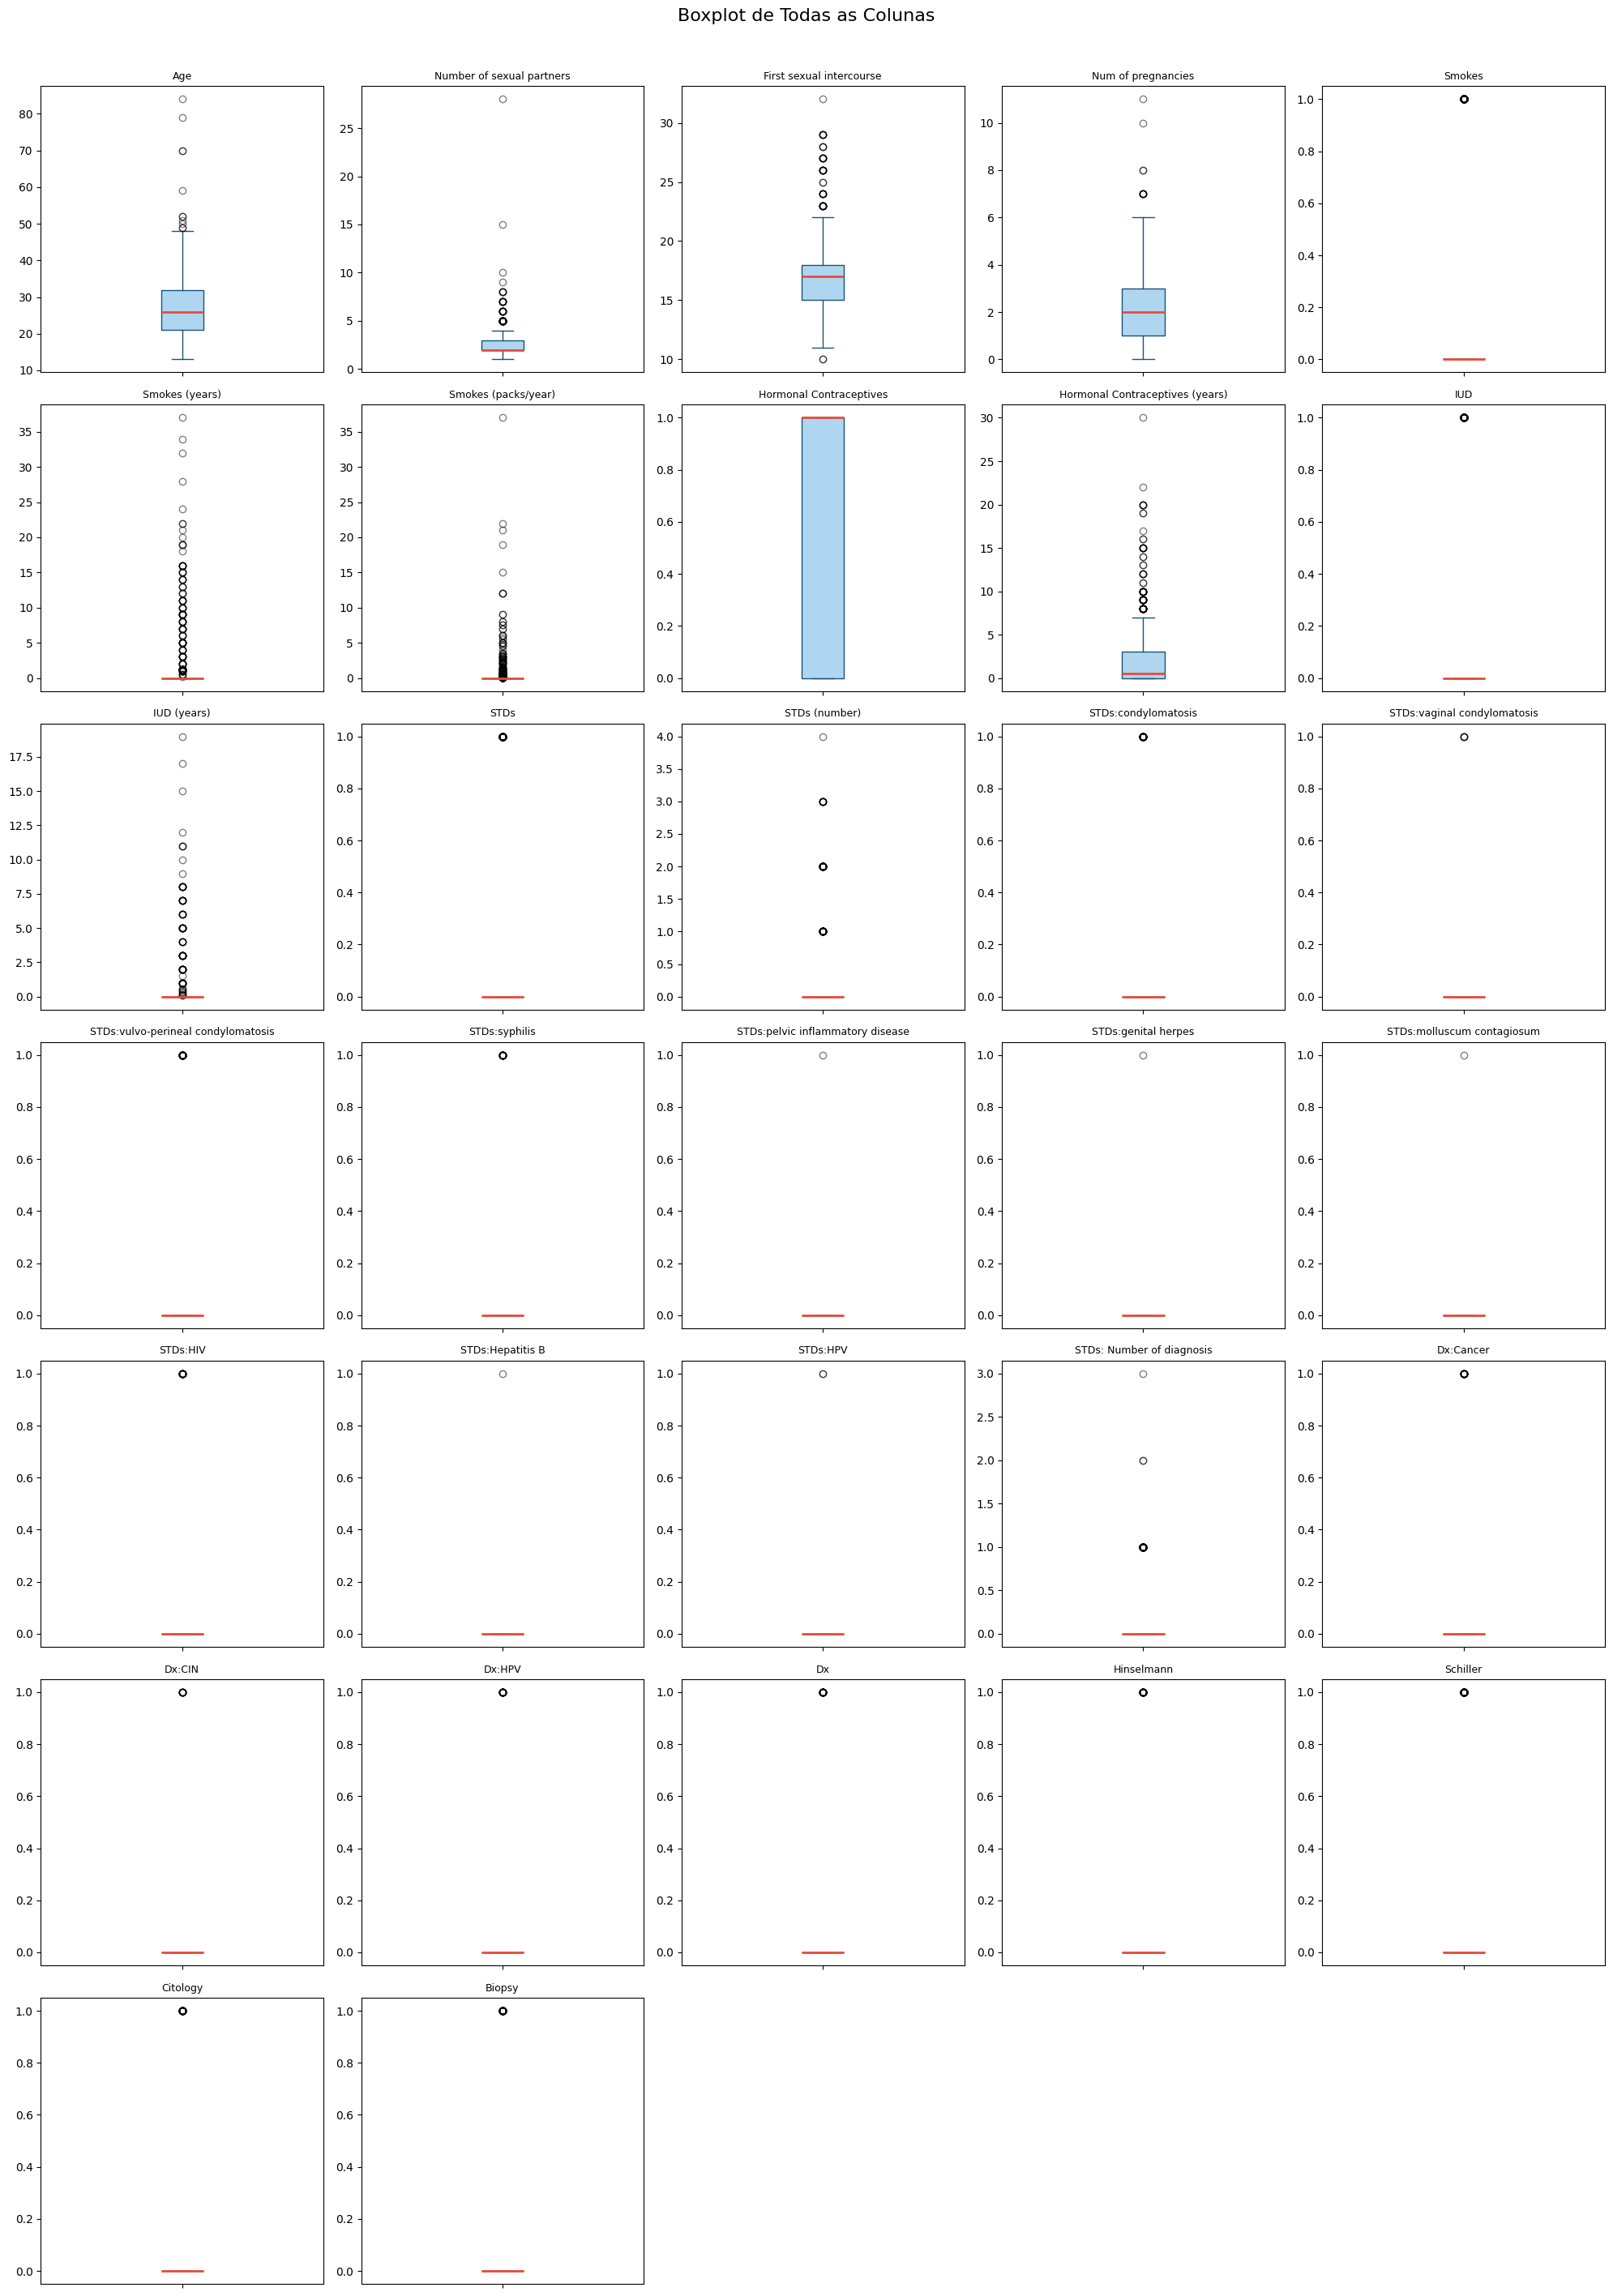

In [245]:
# =============================================================================
# APRESENTA O BOXPLOT DE CADA COLUNA
# =============================================================================

# RELATÓRIO - A partir do bloxpot é possível identificar visualmente possíveis autliers


#seleciona apenas as colunas numéricas
numeric_df = df_tratado.select_dtypes(include="number")

n_cols = 5
n_rows = -(-len(numeric_df.columns) // n_cols)  # arredonda para cima

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    axes[i].boxplot(numeric_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#AED6F1", color="#1A5276"),
                    medianprops=dict(color="#E74C3C", linewidth=2),
                    whiskerprops=dict(color="#1A5276"),
                    capprops=dict(color="#1A5276"),
                    flierprops=dict(marker="o", color="#E74C3C", alpha=0.5))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="x", labelbottom=False)

for j in range(i + 1, len(axes)):  # oculta subplots vazios
    axes[j].set_visible(False)

fig.suptitle("Boxplot de Todas as Colunas", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


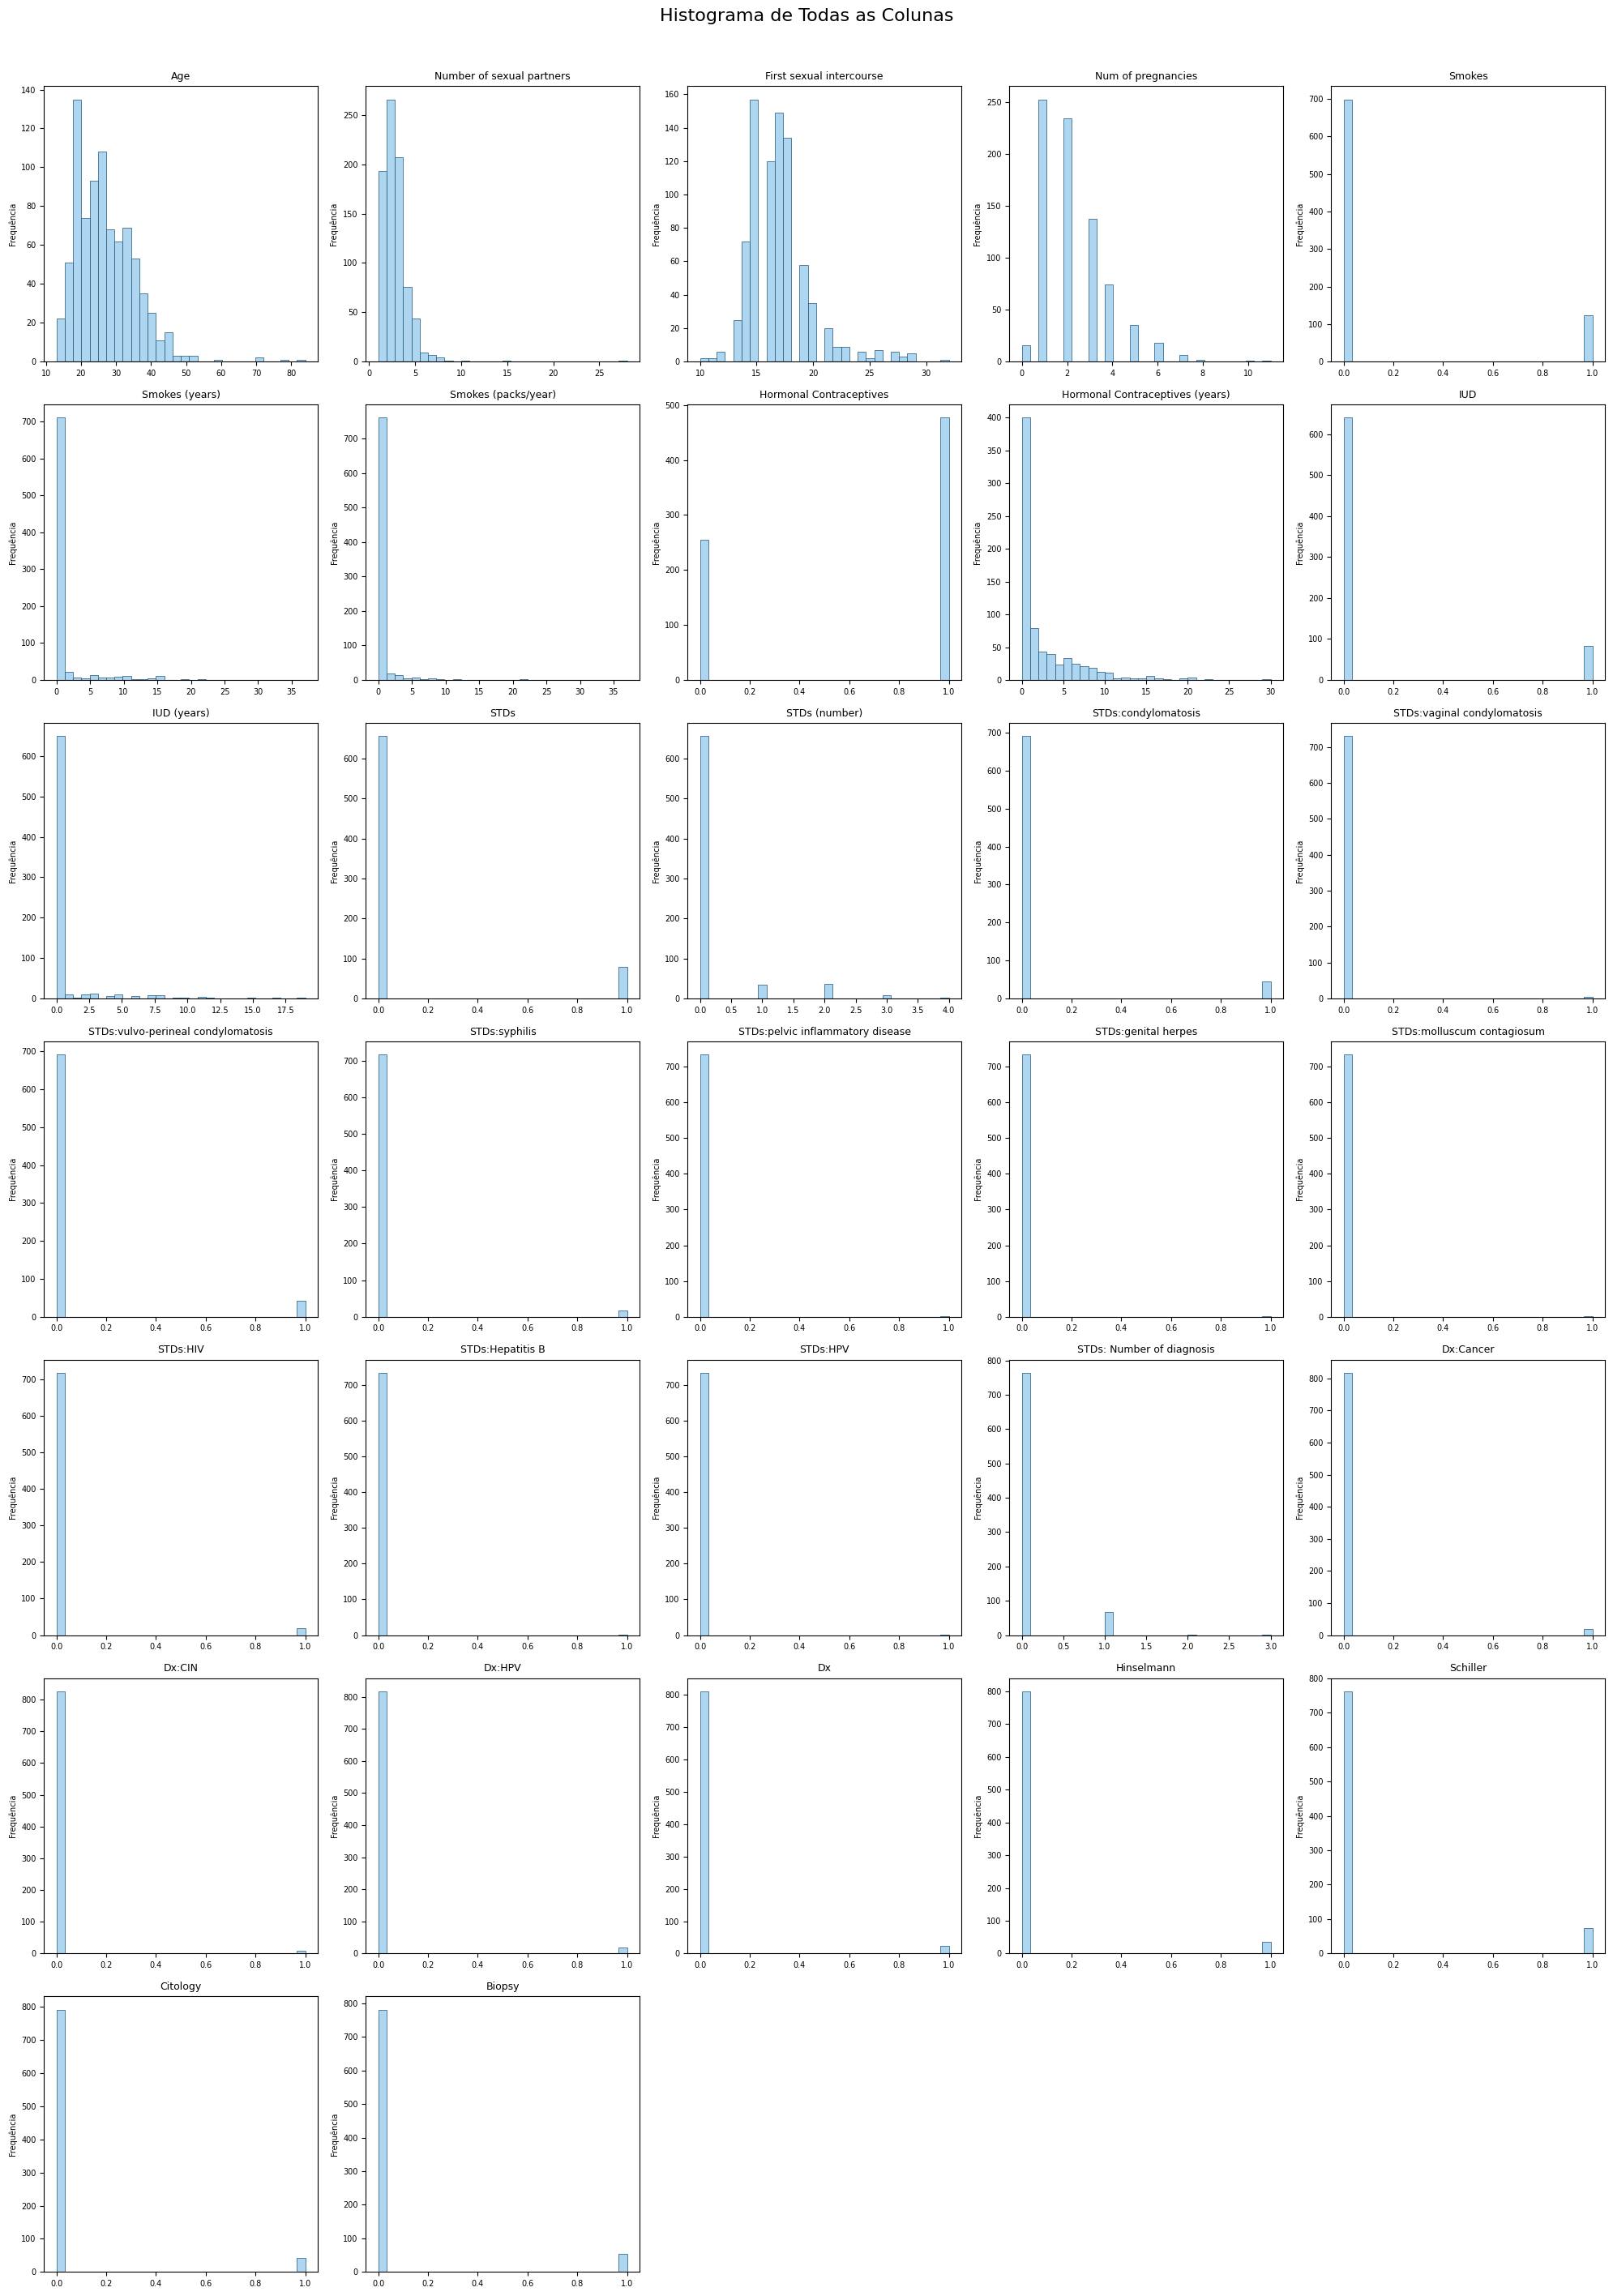

In [246]:

# =============================================================================
# APRESENTA O HISTOGRAMA DE CADA COLUNA
# =============================================================================

# RELATÓRIO - A partir do histograma é possível identificar a distribuição de valores em cada coluna.

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    axes[i].hist(numeric_df[col].dropna(), bins=30,
                 color="#AED6F1", edgecolor="#1A5276", linewidth=0.5)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("Frequência", fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):  # oculta subplots vazios
    axes[j].set_visible(False)

fig.suptitle("Histograma de Todas as Colunas", fontsize=16, y=1.01)
plt.tight_layout()

plt.show()


# Pré-Processamento Refinado e Feature Engineering

In [247]:
# =============================================================================
# SEPARANDO COLUNAS BINARIAS E QUANTITATIVAS
# =============================================================================

#RELATÓRIO - Separação feita com base nos valores apresentados pelo bloxpot

colunas_binarias = [
  "Hormonal Contraceptives",
  "IUD",
  "Smokes",
  "Dx:Cancer",
  "Dx:CIN",
  "Dx:HPV",
  "Dx",
  "STDs",
  "STDs:condylomatosis",
  "STDs:vulvo-perineal condylomatosis",
  "STDs:vaginal condylomatosis",
  "STDs:pelvic inflammatory disease",
  "STDs:syphilis",
  "STDs:genital herpes",
  "STDs:molluscum contagiosum",
  "STDs:HIV",
  "STDs:Hepatitis B",
  "STDs:HPV",
  "Hinselmann",
  "Schiller",
  "Citology",
  "Biopsy"
]

colunas_quantitativas = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Hormonal Contraceptives (years)",
    "Smokes (years)",
    "Smokes (packs/year)",
    "IUD (years)",
    "STDs (number)",
    "STDs: Number of diagnosis",
]

In [248]:
# =============================================================================
# IDENTIFICANDO OUTLIERS POR IQR
# =============================================================================

# Smokes (packs/year) - TEM OUTLIERS - COM BASE NAS ESTATISTICAS

#RELATÓRIO - Outiliers verificado apenas nas colunas quantitativas pois as colunas binarias só armazenam 0 e 1 e neste caso não existe outliers nelas.

# Filtrar apenas as colunas quantitativas
numeric_df = df_tratado[colunas_quantitativas]

Q1  = numeric_df.quantile(0.25)
Q3  = numeric_df.quantile(0.75)
IQR = Q3 - Q1

resultados_iqr = []

for col in numeric_df.columns:
    limite_inferior = Q1[col] - 1.5 * IQR[col]
    limite_superior = Q3[col] + 1.5 * IQR[col]

    n_iqr = ((numeric_df[col] < limite_inferior) |
             (numeric_df[col] > limite_superior)).sum()

    resultados_iqr.append({
        'Coluna'        : col,
        'Lim. Inferior' : round(limite_inferior, 4),
        'Lim. Superior' : round(limite_superior, 4),
        'Outliers IQR'  : n_iqr,
        '% IQR'         : round(n_iqr / len(df_tratado) * 100, 1)
    })

df_iqr = pd.DataFrame(resultados_iqr).sort_values('Outliers IQR', ascending=False)

print("=" * 60)
print("  Outliers identificados por IQR")
print("=" * 60)
print(df_iqr.to_string(index=False))

#RELATÓRIO:
# Limites minimos e máximos com zero - Devido a maior parte absoluta dos valores da coluna serem zero, o limite inferior e superior acabaram ficando como zero.
# Limites inferiores negativos - Quando existe uma dispersçao nos dados, mas com o Q1 ainda baixo
# Valores minimos e maximos para "First sexual intercourse" e "Age" são normais e náo servem para medir outliers
# RESULTADO: IQR não ajudou a identificar outliers

  Outliers identificados por IQR
                         Coluna  Lim. Inferior  Lim. Superior  Outliers IQR  % IQR
            Smokes (packs/year)            0.0            0.0           123   14.7
                 Smokes (years)            0.0            0.0           123   14.7
                    IUD (years)            0.0            0.0            83    9.9
                  STDs (number)            0.0            0.0            79    9.5
      STDs: Number of diagnosis            0.0            0.0            71    8.5
      Number of sexual partners            0.5            4.5            68    8.1
Hormonal Contraceptives (years)           -4.5            7.5            68    8.1
       First sexual intercourse           10.5           22.5            41    4.9
                            Age            4.5           48.5            11    1.3
             Num of pregnancies           -2.0            6.0            10    1.2


In [249]:
# =============================================================================
# IDENTIFICANDO OUTLIERS POR Z-SCORE
# =============================================================================

resultados_z = []

for col in colunas_quantitativas:
    if col not in df_tratado.columns:
        print(f"⚠ Coluna não encontrada no dataframe: {col}")
        continue

    n_z = (abs(stats.zscore(df_tratado[col].dropna())) > 3).sum()

    resultados_z.append({
        'Coluna'               : col,
        'Outliers Z'           : n_z,
        '% Z-Score no dataset' : round(n_z / len(df_tratado) * 100, 1)
    })

df_z = pd.DataFrame(resultados_z).sort_values('Outliers Z', ascending=False)

print("\n" + "=" * 60)
print("  Outliers identificados por Z-Score")
print("=" * 60)
print(df_z.to_string(index=False))


  Outliers identificados por Z-Score
                         Coluna  Outliers Z  % Z-Score no dataset
                  STDs (number)          45                   5.4
                 Smokes (years)          27                   3.2
                    IUD (years)          23                   2.8
       First sexual intercourse          22                   2.6
Hormonal Contraceptives (years)          19                   2.3
            Smokes (packs/year)          14                   1.7
             Num of pregnancies          10                   1.2
      Number of sexual partners           8                   1.0
                            Age           5                   0.6
      STDs: Number of diagnosis           3                   0.4


In [250]:
# =============================================================================
# REGISTROS COMPLETOS IDENTIFICAS COM OUTLIERS POR Z-SCORE
# =============================================================================

print("\n" + "=" * 60)
print("  Registros completos dos Outliers — Z-Score")
print("=" * 60)

indices_todos_outliers = set()

for col in colunas_quantitativas:
    if col not in df_tratado.columns:
        continue

    z_scores        = abs(stats.zscore(df_tratado[col].dropna()))
    indices_outliers = df_tratado[col].dropna().index[z_scores > 3]

    if len(indices_outliers) == 0:
        continue

    # Acumular todos os índices para o resumo final
    indices_todos_outliers.update(indices_outliers)

    print(f"\n  Coluna: {col}  ({len(indices_outliers)} outlier(s))")
    print(f"  {'-' * 50}")
    print(df_tratado.loc[indices_outliers].to_string())

# ── Resumo: todas as linhas únicas que têm ao menos 1 outlier ────────────────
print("\n" + "=" * 60)
print(f"  Registros únicos com ao menos 1 outlier: {len(indices_todos_outliers)}")
print("=" * 60)
print(df_tratado.loc[sorted(indices_todos_outliers)].to_string())

#RELATÓRIO - Ao analisar os registros identificados como outliers usando Z-SCORE , os valores são considerados aceitaveis e não estão muito distantes dos demais valores.
# A quantidade de registros no dataset pode ter influenciado para que esse registros fossem indicados como outliers.


  Registros completos dos Outliers — Z-Score

  Coluna: Age  (5 outlier(s))
  --------------------------------------------------
     Age  Number of sexual partners  First sexual intercourse  Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  Hormonal Contraceptives  Hormonal Contraceptives (years)  IUD  IUD (years)  STDs  STDs (number)  STDs:condylomatosis  STDs:vaginal condylomatosis  STDs:vulvo-perineal condylomatosis  STDs:syphilis  STDs:pelvic inflammatory disease  STDs:genital herpes  STDs:molluscum contagiosum  STDs:HIV  STDs:Hepatitis B  STDs:HPV  STDs: Number of diagnosis  Dx:Cancer  Dx:CIN  Dx:HPV  Dx  Hinselmann  Schiller  Citology  Biopsy
631   59                        2.0                      13.0                 NaN     0.0             0.0             0.000000                      0.0                              0.0  1.0         0.41   0.0            0.0                  0.0                          0.0                                 0.0            0.0  

In [251]:
# =============================================================================
# COMPARATIVO ENTR IQR vs Z-SCORE
# =============================================================================

df_comparativo = pd.merge(df_iqr[['Coluna', 'Outliers IQR', '% IQR']],
                           df_z[['Coluna', 'Outliers Z', '% Z-Score no dataset']],  # ✅ nome correto
                           on='Coluna')

df_comparativo['Diferença']  = df_comparativo['Outliers IQR'] - df_comparativo['Outliers Z']
df_comparativo['Concordam?'] = df_comparativo['Diferença'].apply(
    lambda x: '✔ Sim' if x == 0 else '✘ Não'
)

df_comparativo = df_comparativo.sort_values('Outliers IQR', ascending=False)

print("\n" + "=" * 60)
print("  Comparativo IQR vs Z-Score")
print("=" * 60)
print(df_comparativo.to_string(index=False))

concordam = (df_comparativo['Concordam?'] == '✔ Sim').sum()
discordam = (df_comparativo['Concordam?'] == '✘ Não').sum()
print(f"\n  Colunas onde ambos concordam  : {concordam}")
print(f"  Colunas onde ambos discordam  : {discordam}")
print(f"\n  Dica: IQR é mais sensível a distribuições assimétricas.")
print(f"  Dica: Z-Score assume distribuição normal — menos eficaz com outliers extremos.")



  Comparativo IQR vs Z-Score
                         Coluna  Outliers IQR  % IQR  Outliers Z  % Z-Score no dataset  Diferença Concordam?
            Smokes (packs/year)           123   14.7          14                   1.7        109      ✘ Não
                 Smokes (years)           123   14.7          27                   3.2         96      ✘ Não
                    IUD (years)            83    9.9          23                   2.8         60      ✘ Não
                  STDs (number)            79    9.5          45                   5.4         34      ✘ Não
      STDs: Number of diagnosis            71    8.5           3                   0.4         68      ✘ Não
      Number of sexual partners            68    8.1           8                   1.0         60      ✘ Não
Hormonal Contraceptives (years)            68    8.1          19                   2.3         49      ✘ Não
       First sexual intercourse            41    4.9          22                   2.6         19 

In [252]:
# =============================================================
#  FEATURE ENGENIER - SUBSTITUIR NaN POR ZERO QUANDO COL. PRINCIPAL FOR ZERO
# =============================================================
# REGRA - Subtituir "NaN" por zero quando col. binária da col. principal for zero.

colunas_std = [
    'STDs (number)',
    'STDs:condylomatosis',
    'STDs:vulvo-perineal condylomatosis',
    'STDs:pelvic inflammatory disease',
    'STDs:genital herpes',
    'STDs:molluscum contagiosum',
    'STDs:HIV',
    'STDs:Hepatitis B',
    'STDs:HPV',
    'STDs: Number of diagnosis',
]

regras = {
    'Regra 1 — Smokes=0 e Smokes (years) com "NaN"': {
        'condicao' : (df_tratado['Smokes'] == 0) & (df_tratado['Smokes (years)'].isna()),
        'colunas'  : ['Smokes', 'Smokes (years)', 'Smokes (packs/year)'],
        'alterar'  : ['Smokes (years)', 'Smokes (packs/year)'],
    },
    'Regra 2 — Smokes=0 e Smokes (packs/year) com "NaN"': {
        'condicao' : (df_tratado['Smokes'] == 0) & (df_tratado['Smokes (packs/year)'].isna()),
        'colunas'  : ['Smokes', 'Smokes (packs/year)'],
        'alterar'  : ['Smokes (packs/year)'],
    },
    'Regra 3 — Hormonal Contraceptives=0 e Hormonal Contraceptives (years) com "NaN"': {
        'condicao' : (df_tratado['Hormonal Contraceptives'] == 0) & (df_tratado['Hormonal Contraceptives (years)'].isna()),
        'colunas'  : ['Hormonal Contraceptives', 'Hormonal Contraceptives (years)'],
        'alterar'  : ['Hormonal Contraceptives (years)'],
    },
    'Regra 4 — IUD=0 e IUD (years) com "NaN"': {
        'condicao' : (df_tratado['IUD'] == 0) & (df_tratado['IUD (years)'].isna()),
        'colunas'  : ['IUD', 'IUD (years)'],
        'alterar'  : ['IUD (years)'],
    },
    'Regra 5 — STDs=0 e colunas STDs com "NaN"': {
        'condicao' : (df_tratado['STDs'] == 0) & (df_tratado[[col for col in colunas_std if col in df_tratado.columns]].isna()).any(axis=1),
        'colunas'  : ['STDs'] + [col for col in colunas_std if col in df_tratado.columns],
        'alterar'  : [col for col in colunas_std if col in df_tratado.columns],
    },
}

# ── Aplicar regras ────────────────────────────────────────────────────────────
resumo = {}

for nome_regra, config in regras.items():
    mask      = config['condicao']
    colunas   = config['colunas']
    alterar   = config['alterar']
    registros = df_tratado[mask]

    print(f"\n{'='*60}")
    print(f"  {nome_regra}")
    print(f"  Total de registros alterados: {mask.sum()}")
    print(f"{'='*60}")

    for idx, row in registros.iterrows():
        print(f"\n  Index: {idx}")
        for col in colunas:
            print(f"    {col:<50}: {row[col]}")

    # Substituir "NaN" por 0 nas colunas definidas
    for col in alterar:
        df_tratado.loc[mask, col] = df_tratado.loc[mask, col].replace('?', 0)

    resumo[nome_regra] = mask.sum()

# ── Resumo geral ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  RESUMO GERAL")
print(f"{'='*60}")
for nome_regra, total in resumo.items():
    print(f"  {nome_regra:<55}: {total} registros")
print(f"\n  Total geral alterado: {sum(resumo.values())} registros")


  Regra 1 — Smokes=0 e Smokes (years) com "NaN"
  Total de registros alterados: 0

  Regra 2 — Smokes=0 e Smokes (packs/year) com "NaN"
  Total de registros alterados: 0

  Regra 3 — Hormonal Contraceptives=0 e Hormonal Contraceptives (years) com "NaN"
  Total de registros alterados: 0

  Regra 4 — IUD=0 e IUD (years) com "NaN"
  Total de registros alterados: 0

  Regra 5 — STDs=0 e colunas STDs com "NaN"
  Total de registros alterados: 0

  RESUMO GERAL
  Regra 1 — Smokes=0 e Smokes (years) com "NaN"          : 0 registros
  Regra 2 — Smokes=0 e Smokes (packs/year) com "NaN"     : 0 registros
  Regra 3 — Hormonal Contraceptives=0 e Hormonal Contraceptives (years) com "NaN": 0 registros
  Regra 4 — IUD=0 e IUD (years) com "NaN"                : 0 registros
  Regra 5 — STDs=0 e colunas STDs com "NaN"              : 0 registros

  Total geral alterado: 0 registros


In [253]:
# =============================================================================
# INPUTANDO VALORES PARA SUBSTITUIR "NaN" - DATA IMPUTATION
# =============================================================================

# RELATÓRIO -
# Para as colunas binárias foram inputados valores com base ne estratégia de MODA
# pois os valores a serem imputados tem que existir na coluna, ou seja "0" ou "1".

# Para as colunas quantitativas foram inputados valores com base ne estratégia de MÉDIA.

# Média — indicada para variáveis numéricas sem outliers
# imputer = SimpleImputer(strategy='mean')

# Mediana — indicada para variáveis numéricas com outliers
# imputer = SimpleImputer(strategy='median')

# Moda — indicada para variáveis categóricas ou binárias
# imputer = SimpleImputer(strategy='most_frequent')


# ── 1. Imputar colunas binárias — estratégia: MODA ───────────────────────────
imputer_bin = SimpleImputer(strategy='most_frequent')

print(f"\n{'='*60}")
print(f"  Colunas Binárias — Imputação pela MODA")
print(f"{'='*60}")

for col in colunas_binarias:
    if col in df_tratado.columns:
        n_ausentes = df_tratado[col].isnull().sum()
        if n_ausentes > 0:
            moda = df_tratado[col].mode()[0]
            print(f"\n  Coluna  : {col}")
            print(f"  Moda    : {moda}")
            print(f"  Ausentes: {n_ausentes} registros")
            df_tratado[col] = imputer_bin.fit_transform(df_tratado[[col]]).ravel()

# ── 2. Imputar colunas numéricas — estratégia: MEDIA ───────────────────────
imputer_num = SimpleImputer(strategy='mean')

print(f"\n{'='*60}")
print(f"  Colunas Numéricas — Imputação pela MEDIA")
print(f"{'='*60}")

for col in colunas_quantitativas:
    if col in df_tratado.columns:
        n_ausentes = df_tratado[col].isnull().sum()
        if n_ausentes > 0:
            mediana = df_tratado[col].median()
            print(f"\n  Coluna  : {col}")
            print(f"  Mediana : {mediana}")
            print(f"  Ausentes: {n_ausentes} registros")
            df_tratado[col] = imputer_num.fit_transform(df_tratado[[col]]).ravel()

# ── 3. Verificar se ainda há ausentes ────────────────────────────────────────
ausentes_restantes = df_tratado.isnull().sum().sum()
print(f"\n{'='*60}")
print(f"  RESUMO FINAL")
print(f"{'='*60}")
print(f"  Valores ausentes restantes: {ausentes_restantes}")
if ausentes_restantes == 0:
    print("  ✔ Todos os valores ausentes foram imputados!")
else:
    print("  ⚠ Ainda há valores ausentes:")
    print(df_tratado.isnull().sum()[df_tratado.isnull().sum() > 0])




  Colunas Binárias — Imputação pela MODA

  Coluna  : Hormonal Contraceptives
  Moda    : 1.0
  Ausentes: 103 registros

  Coluna  : IUD
  Moda    : 0.0
  Ausentes: 112 registros

  Coluna  : Smokes
  Moda    : 0.0
  Ausentes: 13 registros

  Coluna  : STDs
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:condylomatosis
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:vulvo-perineal condylomatosis
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:vaginal condylomatosis
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:pelvic inflammatory disease
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:syphilis
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:genital herpes
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:molluscum contagiosum
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:HIV
  Moda    : 0.0
  Ausentes: 100 registros

  Coluna  : STDs:Hepatitis B
  Moda    : 0.0
  Ausentes: 100 registros



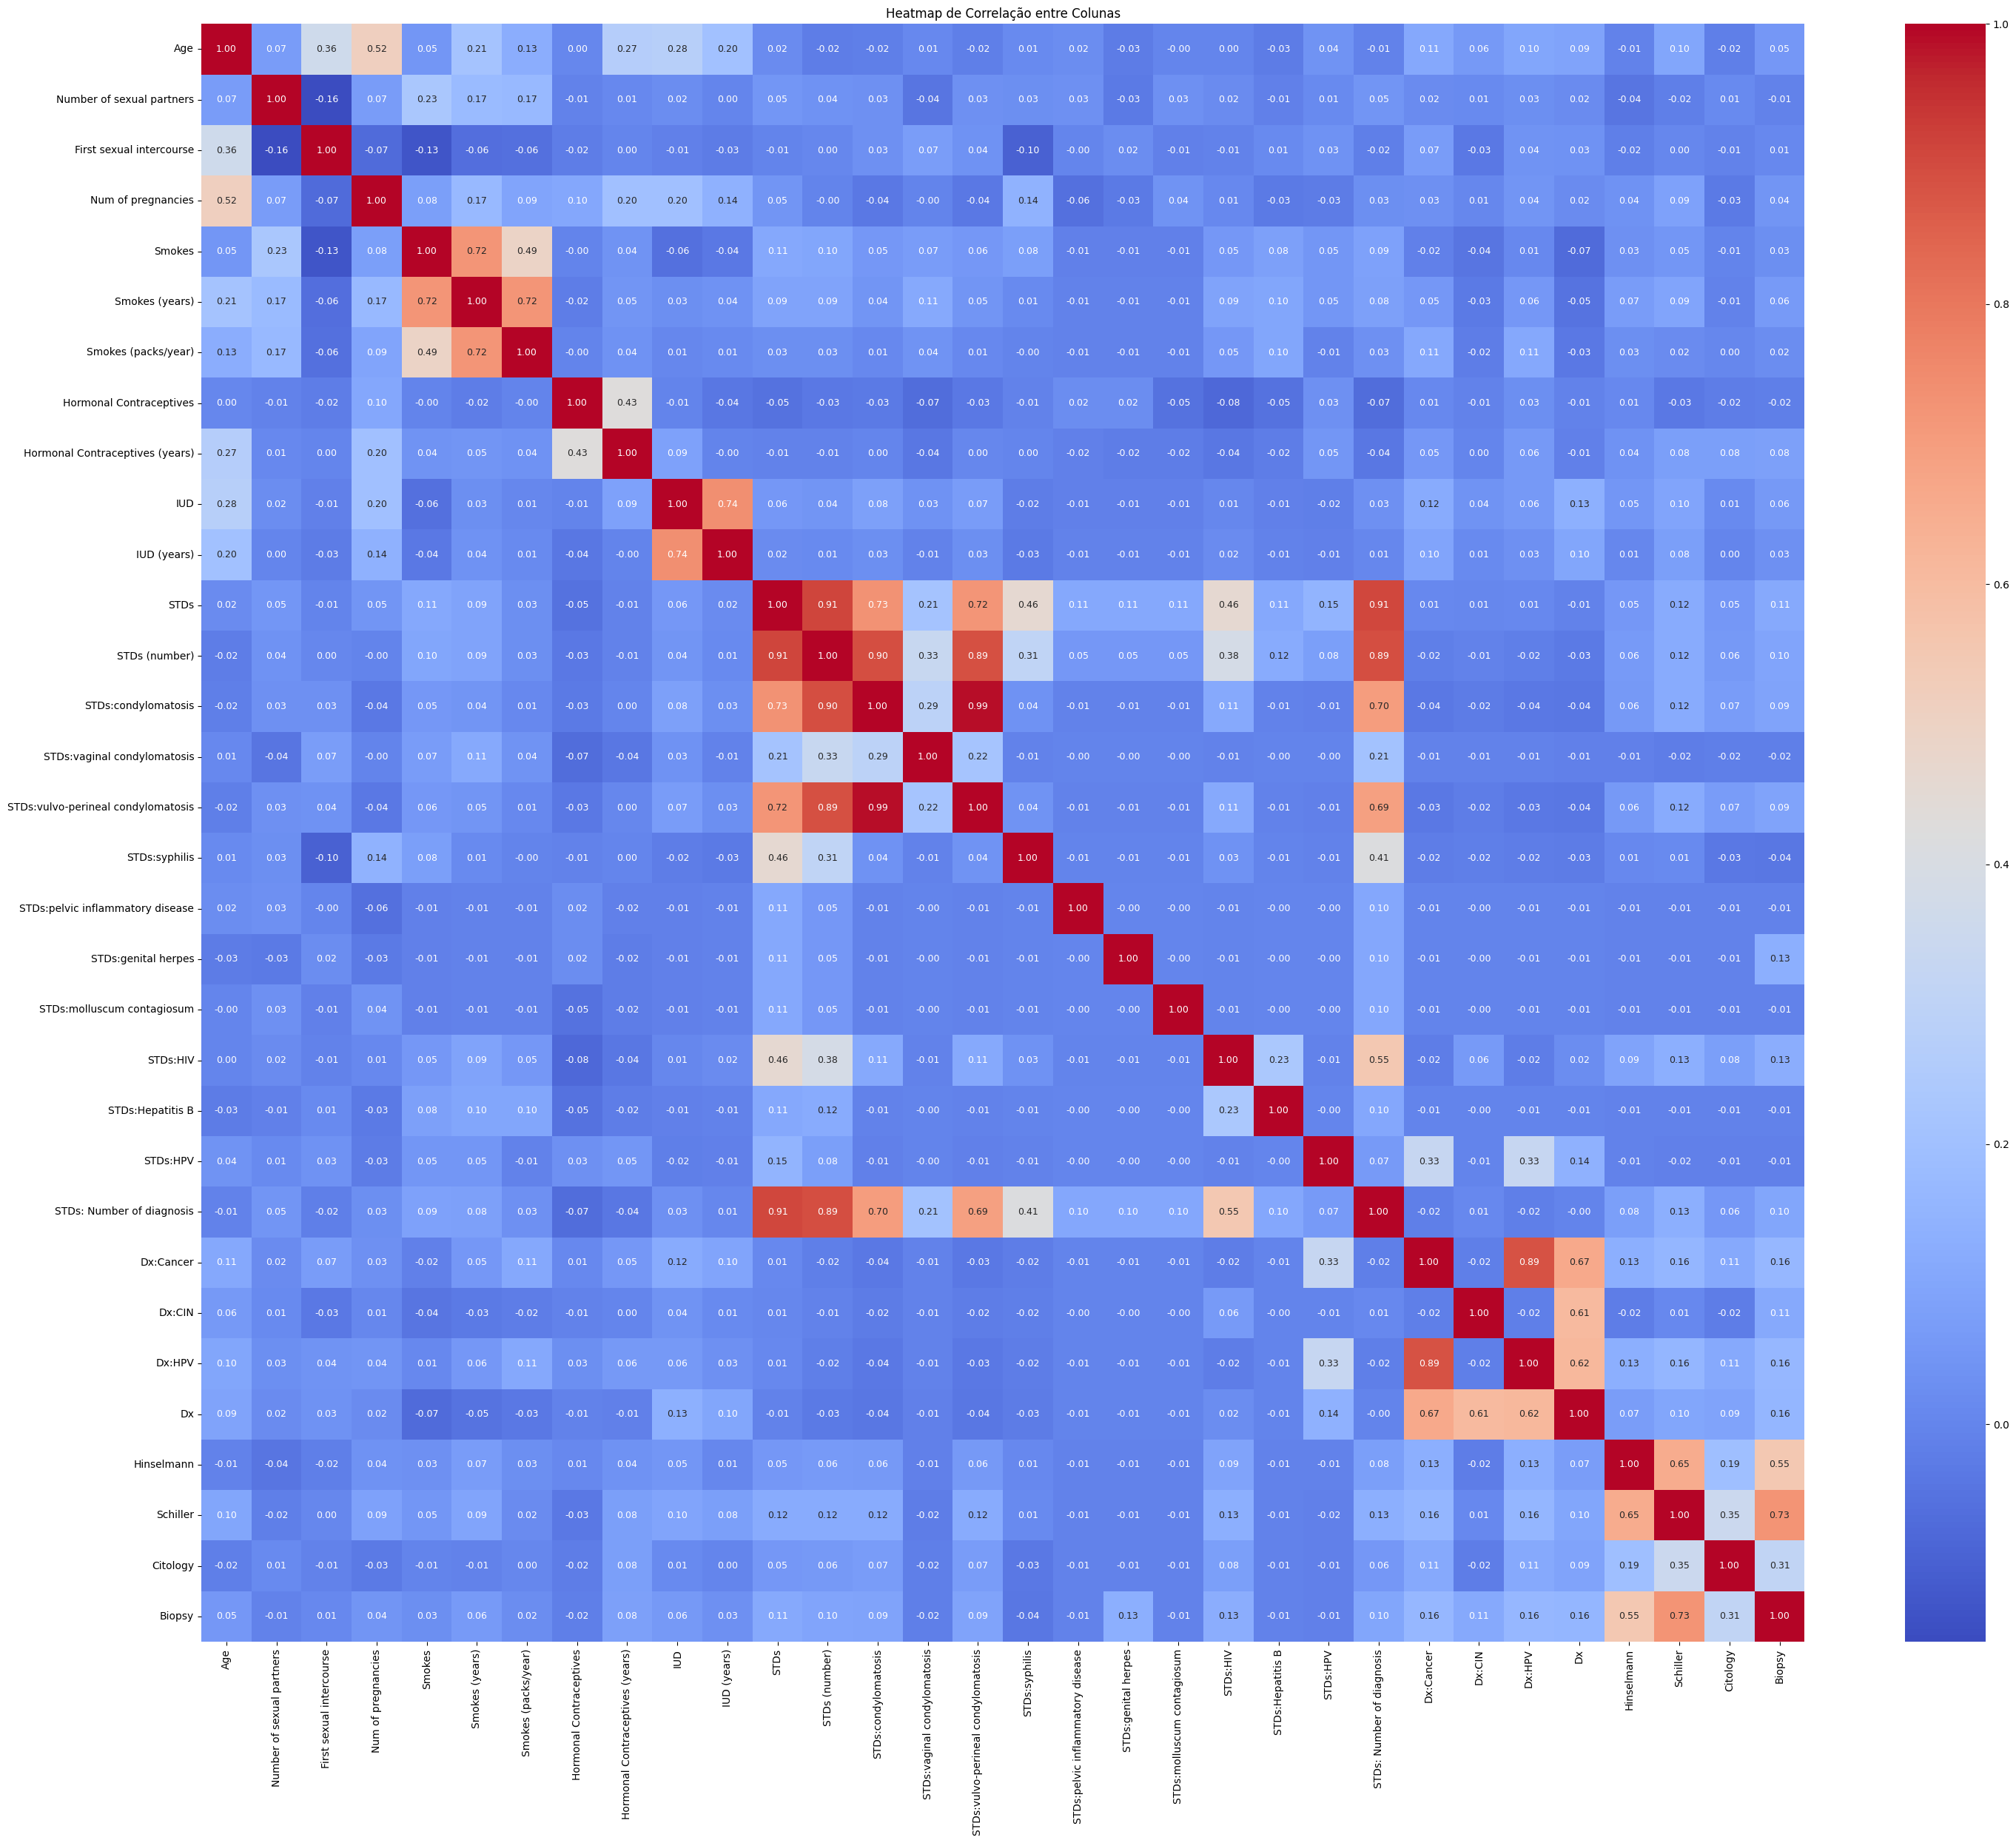

In [254]:
# =============================================================================
# ANALISE DE CORRELACIONAMENTO - HEATMAP
# =============================================================================
correlacao = df_tratado.corr()
plt.figure(figsize=(30, 25))  # aumentar bastante
sns.heatmap(correlacao, annot=True, fmt=".2f",
            annot_kws={"size": 9},  # fonte menor
            cmap='coolwarm')
plt.title("Heatmap de Correlação entre Colunas")
plt.tight_layout()

plt.show()

In [255]:
# =============================================================
# REMOVE COLUNAS COM ALTA CORRELAÇÃO COM A COLUNA TARGET BIOPSY
# =============================================================

# RELATÓRIO - Ao remover as colunas "Hinselmann", "Schiller", "Citology" por serem também colunas target e as ter altas correlações com a coluna target Biopsy, a  avaliação de todos os modelos testados cairam.
# Com isso as colunas tiverem que ser reincluidas no dataset.

#6. Divisão dos Dados — Treino e Teste


In [256]:
# =============================================================
# DIVINDO OS DADOS ENTRE TREINO E TESTE
# =============================================================

# Separando features e target
X = df_tratado.drop(columns=[target])
y = df_tratado[target]
#y = y.map({1: 0, 2: 1}) # Coluna target com valores 1 e 2. Alterado para 0 e 1 para funcionar o XGBoost

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,        # 70% treino | 30% teste
    stratify=y,           # mantém proporção dos valores da coluna target
    random_state=42)

print(f"Treino : {X_train.shape[0]} registros")
print(f"Teste  : {X_test.shape[0]} registros")

Treino : 584 registros
Teste  : 251 registros


#7. Treinamento dos Modelos

In [257]:
# =========================================================================
# APLICANDO STANDARD SCALLER PARA PRODINIZAR OS VALORES NA MESMA ESCALA
# =========================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [258]:
# =========================================================================
# TESTANDO REGRESSÃO LOGISTICA
# =========================================================================

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    solver='saga',        # melhor para datasets desbalanceados
    penalty='elasticnet', # combina L1 + L2, mais robusto que apenas 'l2'
    l1_ratio=0.5,         # proporção L1/L2 — pode variar entre 0 e 1
    C=0.1                 # mais regularização (padrão é 1.0) — reduz falsos positivos
)

# Ou via GridSearch para encontrar o melhor C e l1_ratio:
params = {
    'C': [0.01, 0.1, 0.5, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
grid_lr = GridSearchCV(lr, params, scoring='f1', cv=5)
grid_lr.fit(X_train_scaled, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=5,
             estimator=LogisticRegression(C=0.1, class_weight='balanced',
                                          l1_ratio=0.5, max_iter=5000,
                                          penalty='elasticnet', random_state=42,
                                          solver='saga'),
             param_grid={'C': [0.01, 0.1, 0.5, 1.0],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='f1')

In [ ]:
# =========================================================================
# TESTANDO RANDOM FOREST
# =========================================================================

rf = RandomForestClassifier(
    n_estimators=500,          # mais árvores = mais estabilidade (era 100)
    class_weight='balanced_subsample',  # mais eficaz que 'balanced' para RF
    max_depth=10,              # limita overfitting
    min_samples_leaf=2,        # evita folhas com 1 amostra
    min_samples_split=5,
    max_features='sqrt',       # padrão, mas vale deixar explícito
    n_jobs=-1,
    random_state=42
)

# Ou GridSearch focando em recall:
params = {
    'n_estimators': [200, 500],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}
grid_rf = GridSearchCV(rf, params, scoring='recall', cv=5)
grid_rf.fit(X_train_scaled, y_train)



In [ ]:
# =========================================================================
# TESTANDO XGB CLASSIFIER
# =========================================================================

# Calcule o peso correto com base no seu y_train real
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos  # ex: ~14.0 para 93.4% / 6.6%

xgb = XGBClassifier(
    scale_pos_weight=scale,   # valor calculado dinamicamente
    n_estimators=300,
    learning_rate=0.05,       # menor = mais conservador (era padrão 0.3)
    max_depth=4,              # era padrão 6 — reduz overfitting
    subsample=0.8,            # amostragem por árvore
    colsample_bytree=0.8,     # amostragem de features por árvore
    min_child_weight=5,       # exige mais amostras por folha — ajuda no desbalanceamento
    random_state=42,
    eval_metric='aucpr'       # AUC-PR é mais informativa que logloss em dados desbalanceados
)

xgb.fit(X_train_scaled, y_train)  # ✅ treina o modelo

In [ ]:
# =========================================================================
# TESTANDO KNM
# =========================================================================

# Ajuste 1: buscar o melhor K com scoring em recall
params = {'n_neighbors': [3, 5, 7, 11, 15, 21]}
grid_knn = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    params,
    scoring='recall',  # prioriza detectar os positivos
    cv=5
)
grid_knn.fit(X_train_scaled, y_train)

# Ajuste 2: usar distância ponderada (vizinhos mais próximos têm mais peso)
knn = KNeighborsClassifier(
    n_neighbors=grid_knn.best_params_['n_neighbors'],
    weights='distance',  # era padrão 'uniform'
    metric='manhattan',  # testar também 'euclidean' e 'minkowski'
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)  # ✅ adicione esta linha

In [ ]:
# =========================================================================
# TESTANDO SVM
# =========================================================================

svm = SVC(
    class_weight='balanced',
    kernel='rbf',
    probability=True,
    random_state=42,
    C=10,        # aumentar C = menos margem, mais acertos nos positivos
    gamma='scale'  # deixar explícito
)

svm.fit(X_train_scaled, y_train)

# ✅ Calcular threshold no conjunto de TREINO com cross_val_predict
from sklearn.model_selection import cross_val_predict

probs_train = cross_val_predict(
    svm, X_train_scaled, y_train,
    cv=5,
    method='predict_proba'
)[:, 1]

# Otimizar threshold nos dados de treino
precisoes, recalls, thresholds = precision_recall_curve(y_train, probs_train)
f1_scores = 2 * (precisoes * recalls) / (precisoes + recalls + 1e-9)
melhor_threshold = thresholds[np.argmax(f1_scores)]

print(f"Melhor threshold encontrado no treino: {melhor_threshold:.4f}")

# ✅ Aplicar no teste — agora sim uma avaliação honesta
probs_test = svm.predict_proba(X_test_scaled)[:, 1]
y_pred_ajustado = (probs_test >= melhor_threshold).astype(int)


#8. Avaliação dos Modelos

##Metrica mais importante para essa trabalho é RECALL. Dica da Professora Medica.

*   Com Câncer    0.73   ← Sensibilidade
*   Sem Câncer    0.80   ← Especificidade

## Valores mínimos esperados

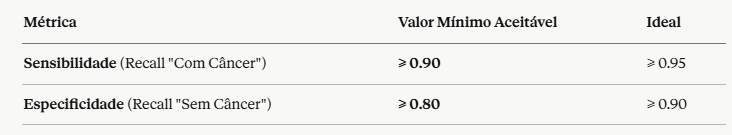




In [ ]:
# =========================================================================
#  MODELOS A SEREM AVALIADOS
# =========================================================================

modelos = {
    'Regressão Logística' : grid_lr.best_estimator_,
    'Random Forest'       : grid_rf.best_estimator_,
    'XGBoost'             : xgb,
    'KNN'                 : knn,
    'SVM'                 : svm
}


In [ ]:
# ================================================
# Curva ROC — Todos os Modelos
# ================================================

fig, ax = plt.subplots(figsize=(8, 6))

for nome, modelo in modelos.items():
    RocCurveDisplay.from_estimator(modelo, X_test_scaled, y_test, ax=ax, name=nome)

ax.set_title('Curva ROC — Comparativo dos Modelos')
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Taxa de Verdadeiro Positivo')
plt.tight_layout()
plt.show()

In [ ]:
# ================================================
# COMPARANDO O RESULTADO DE TODOS OS MODELOS
# ================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = []

for nome, modelo in modelos.items():


    scores = cross_validate(
        modelo, X_train_scaled, y_train,
        cv=cv,
        scoring=['f1', 'roc_auc'],
        return_train_score=False
    )
    f1_cv  = scores['test_f1'].mean()
    auc_cv = scores['test_roc_auc'].mean()
    f1_std  = scores['test_f1'].std()
    auc_std = scores['test_roc_auc'].std()

    # ── Avaliação no Test Set ─────────────────────────────────────────────────
    y_pred      = modelo.predict(X_test_scaled)
    y_pred_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    f1_test     = f1_score(y_test, y_pred)
    auc_test    = roc_auc_score(y_test, y_pred_prob)

    resultados.append({
        'Modelo'        : nome,
        'F1 CV'         : round(f1_cv, 4),
        'F1 CV Std'     : round(f1_std, 4),
        'AUC CV'        : round(auc_cv, 4),
        'AUC CV Std'    : round(auc_std, 4),
        'F1 Teste'      : round(f1_test, 4),
        'AUC Teste'     : round(auc_test, 4)
    })


    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    print(f"  F1  CV   : {f1_cv:.4f} ± {f1_std:.4f}")
    print(f"  AUC CV   : {auc_cv:.4f} ± {auc_std:.4f}")
    print(f"  F1  Test : {f1_test:.4f}")
    print(f"  AUC Test : {auc_test:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Sem Câncer', 'Com Câncer'])}")

df_resultados = pd.DataFrame(resultados).sort_values('AUC CV', ascending=False)
print("\n### Comparativo Final dos Modelos ###")
print(df_resultados.to_string(index=False))


